<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/Stock%20market%20regression%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/Applied ML lab/EXPERIMENT 2,3,4/stock_price_with_price_column.csv"

In [ ]:
df = pd.read_csv(file_path)

print(df.head())
print(df.info())

         Date Stock    Open    High     Low   Close   Volume       Price
0  2020-01-01  AAPL  173.80  174.75  173.68  174.43  8204212  174.286667
1  2020-01-02  AAPL  176.01  177.59  174.07  177.55  2766891  176.403333
2  2020-01-03  AAPL  177.57  178.37  176.62  176.71  5721339  177.233333
3  2020-01-06  AAPL  176.01  177.58  171.33  171.73  9242680  173.546667
4  2020-01-07  AAPL  171.85  172.20  170.69  170.82  4416664  171.236667
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6525 entries, 0 to 6524
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6525 non-null   object 
 1   Stock   6525 non-null   object 
 2   Open    6525 non-null   float64
 3   High    6525 non-null   float64
 4   Low     6525 non-null   float64
 5   Close   6525 non-null   float64
 6   Volume  6525 non-null   int64  
 7   Price   6525 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 407.9+ KB
None


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [ ]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Price']


In [ ]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


MSE: 0.0650073473910665
R2: 0.9998868113956694


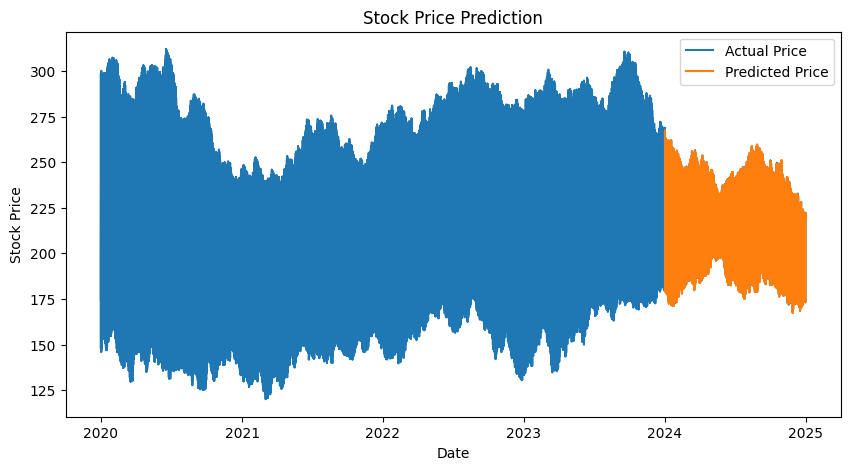

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Price'], label="Actual Price")
plt.plot(df['Date'][split_index:], y_pred, label="Predicted Price")

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.legend()
plt.show()


In [ ]:
X = df[['Open']]
y = df['Price']


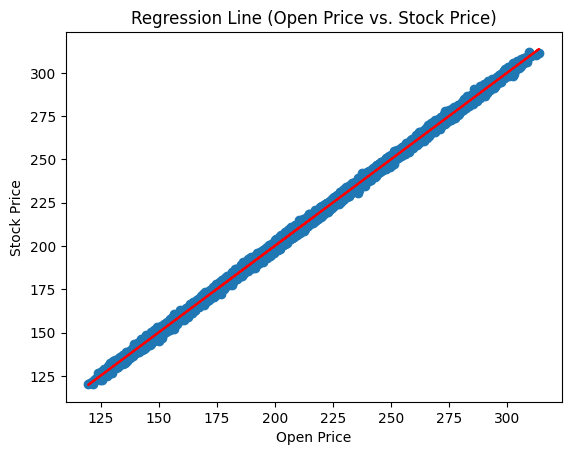

In [ ]:
# Train a new simple linear regression model using only 'Open'
simple_model = LinearRegression()
simple_model.fit(df[['Open']], df['Price'])

plt.scatter(df['Open'], df['Price'])
plt.plot(df['Open'], simple_model.predict(df[['Open']]), color='red')
plt.xlabel("Open Price")
plt.ylabel("Stock Price")
plt.title("Regression Line (Open Price vs. Stock Price)")
plt.show()